In [1]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "DesyneMartinez"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:

setwd("STAT-7110-Quality-Control//Assignments//HW2")

## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 9, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis
The purpose of this analysis is to investigate the pour consistency at the bar's main tap station to get it up to par with the target pour volume of 16 ounces. The CO2 regulator at the bar's tap station is having liquid creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour named in the complaint data for many customers going to the bar.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.
The quality characteristic we will monitor is the Pour Consistency at the tap station. This is measured in ounces and is a continuous variable with numeric data.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

Given the scenario a CUSUM and EWMA chart would be appropriate to use since we are analyzing a small sustained drift in the CO2 regulator when it comes to pour consistency. These Charts are sensitive to small shifts in the process mean and draws on the entire sequence of points rather than just the latest one. The CUSUM chart does have some tradeoffs because it is a complex chart to interpret while also being less obvious on how to set the control parameters, H  and K. The EWMA chart has a similar tradeoff with the control limits L and lamda being subjective and the choices can impact the performance of the chart. For the sake of interpretability the EWMA chart has a great utilization since it weights the observations to produce a moving average making it much more simpler to implement and interpret than the CUSUM chart.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [10]:
## Q4 Code ##
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages( "qcc")

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Data ##

BSPhase1_df <- read_excel("BustersSportsBar_PhaseI.xlsx")

## Data Integrity Check ##

BSPhase1_df |>
  glimpse()

#We are asked to estimate the standard deviation using the range method and get the subgroup means.

#range(BSPhase1_df$Shift, na.rm = FALSE, finite = FALSE)

## Estimate process mean ##

#mu0 <- mean(BSPhase1_df$Shift)

## Estimate process standard deviation ##

#sigma_hat <- sd(BSPhase1_df$Shift)

#cat(" Process mean:", mu0, "\n")
#cat(" Process Standard Deviation:", sigma_hat, "\n")

#summary(BSPhase1_df$Shift)

#Calculating all the Subgroup Means individually
Pourmean_1 <- mean(BSPhase1_df$Pour1)
Pourmean_2 <- mean(BSPhase1_df$Pour2)
Pourmean_3 <- mean(BSPhase1_df$Pour3)
Pourmean_4 <- mean(BSPhase1_df$Pour4)
Pourmean_5 <- mean(BSPhase1_df$Pour5)

cat("Subgroup Means:", "\n")

cat("Subgroup Mean 1:", Pourmean_1 , "\n")
cat("Subgroup Mean 1:", Pourmean_2 , "\n")
cat("Subgroup Mean 3:", Pourmean_3, "\n")
cat("Subgroup Mean 4:", Pourmean_4, "\n")
cat("Subgroup Mean 5:", Pourmean_5, "\n")

#Calculating the Ranges
PourRange_1 <- range(BSPhase1_df$Pour1, na.rm = FALSE, finite = FALSE)
PourRange_2 <- range(BSPhase1_df$Pour2, na.rm = FALSE, finite = FALSE)
PourRange_3 <- range(BSPhase1_df$Pour3, na.rm = FALSE, finite = FALSE)
PourRange_4 <- range(BSPhase1_df$Pour4, na.rm = FALSE, finite = FALSE)
PourRange_5 <- range(BSPhase1_df$Pour5, na.rm = FALSE, finite = FALSE)

cat("Subgroup Ranges:", "\n")

cat("Subgroup Range 1:", PourRange_1 , "\n")
cat("Subgroup Range 2:", PourRange_2 , "\n")
cat("Subgroup Range 3:", PourRange_3 , "\n")
cat("Subgroup Range 4:", PourRange_4 , "\n")
cat("Subgroup Range 5:", PourRange_5 , "\n")


# Compute subgroup means and ranges together to estimate the process mean and Standard deviation
BSPhase1_new <- BSPhase1_df |>
  rowwise() |>
  mutate(
    subgroup_mean = mean(c(Pour1, Pour2, Pour3, Pour4, Pour5)),
    subgroup_range = max(c(Pour1, Pour2, Pour3, Pour4, Pour5)) -
                     min(c(Pour1, Pour2, Pour3, Pour4, Pour5))
  ) |>
  ungroup()


# Process mean = mean of subgroup means
process_mean <- mean(BSPhase1_new$subgroup_mean)

# Average range
Rbar <- mean(BSPhase1_new$subgroup_range)

# d2 constant for subgroup size n = 5
d2 <- 2.326

# Range-based estimate of sigma
sigma_hat <- Rbar / d2

cat("Process Mean:", process_mean, "\n")
cat("Process Standard Deviation (Using the Range Method):", sigma_hat, "\n")







Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…
Subgroup Means: 
Subgroup Mean 1: 16.04821 
Subgroup Mean 1: 16.07983 
Subgroup Mean 3: 16.04405 
Subgroup Mean 4: 15.98867 
Subgroup Mean 5: 16.03204 
Subgroup Ranges: 
Subgroup Range 1: 15.7681 16.2143 
Subgroup Range 2: 15.697 16.3792 
Subgroup Range 3: 15.8021 16.2208 
Subgroup Range 4: 15.6877 16.1273 
Subgroup Range 5: 15.5843 16.1363 
Process Mean: 16.03856 
Process Standard Deviation (Using the Range Method): 0.07718659 


The process mean is estimated to be $16$. which is in conjunction with the 5 subgroup means since they are all roughly around 16 which is the target pour consistency that the CO2 regulator should be doing at the bar's tap station.

When calcualting the ranges for the subgroups it estimated
The Process Standard Deviation is to be $0.077$. This indicates a very small shift in the variation for the pour consistency in the C02 regulator in which if there are any inconsistencies with the pouring mechanic a Skewhart chart would not be able to easily detect, but we will construct a Phase 1 R chart to identify if there are any OOC points that need to be observed.


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

[1] 19


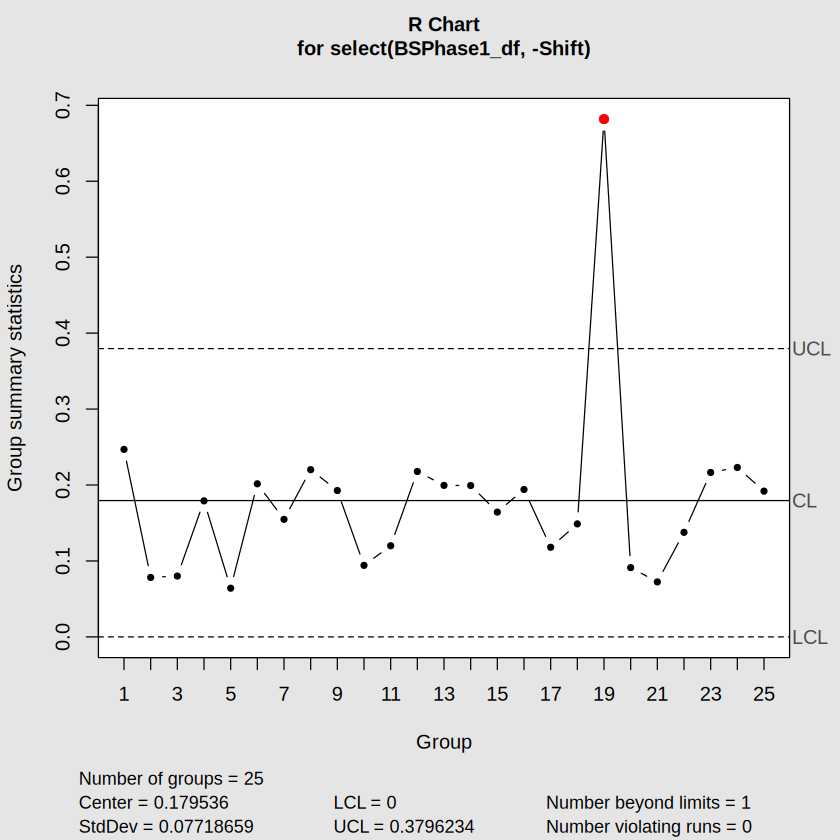

List of 11
 $ call      : language qcc(data = select(newphase1, -Shift), type = "R", plot = TRUE)
 $ type      : chr "R"
 $ data.name : chr "select(newphase1, -Shift)"
 $ data      : num [1:24, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 0.2469 0.0783 0.0801 0.1791 0.0641 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 0.159
 $ std.dev   : num 0.0682
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 0 0.335
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

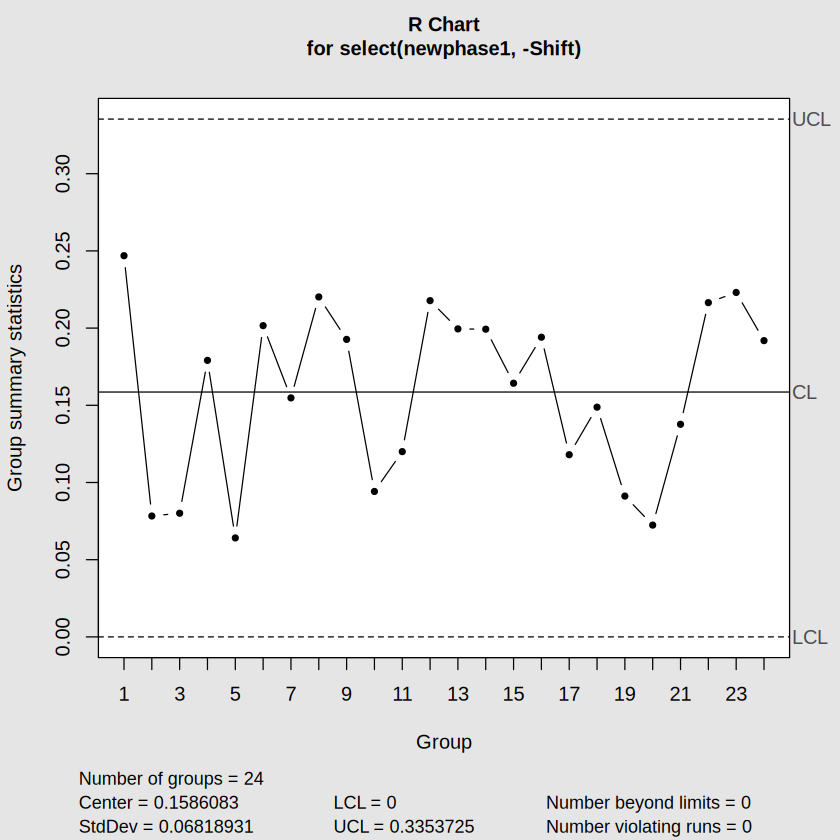

In [12]:
## Q5 Code ##


#Generating the Phase1 R chart
phase1_r <- qcc(BSPhase1_df |> select(-`Shift`),
                 type = "R",
                 plot = TRUE)

ooc_indices <- phase1_r$violations$beyond.limits
print(ooc_indices)

cleanphase1 <- setdiff(1:nrow(BSPhase1_df), ooc_indices)
newphase1 <- BSPhase1_df[cleanphase1, ]

phase1_Rnew <- qcc(newphase1 |> select(-`Shift`),
                 type = "R",
                 plot = TRUE)
                 (phase1_Rnew)


After generating the R chart it showcased to not have statistical control. As we inspected the chart subgroup number 19 showed the variation to be beyond the upper control limit. This may lead to evidence that the CO2 regulator may have inconsistencies in its pouring mechanic. By removing subgroup 19 the R chart showcased no other groups exceeding or below the respective limits which alerts us to possible statistical control! With this information we can proceed by constructing the X bar chart with these subgroups retained.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

List of 11
 $ call      : language qcc(data = select(newphase1, -Shift), type = "xbar", plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "select(newphase1, -Shift)"
 $ data      : num [1:24, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:24] 16.1 16.1 16.1 16.1 16 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes     : int [1:24] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16
 $ std.dev   : num 0.0682
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 15.9 16.1
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

[1] 12


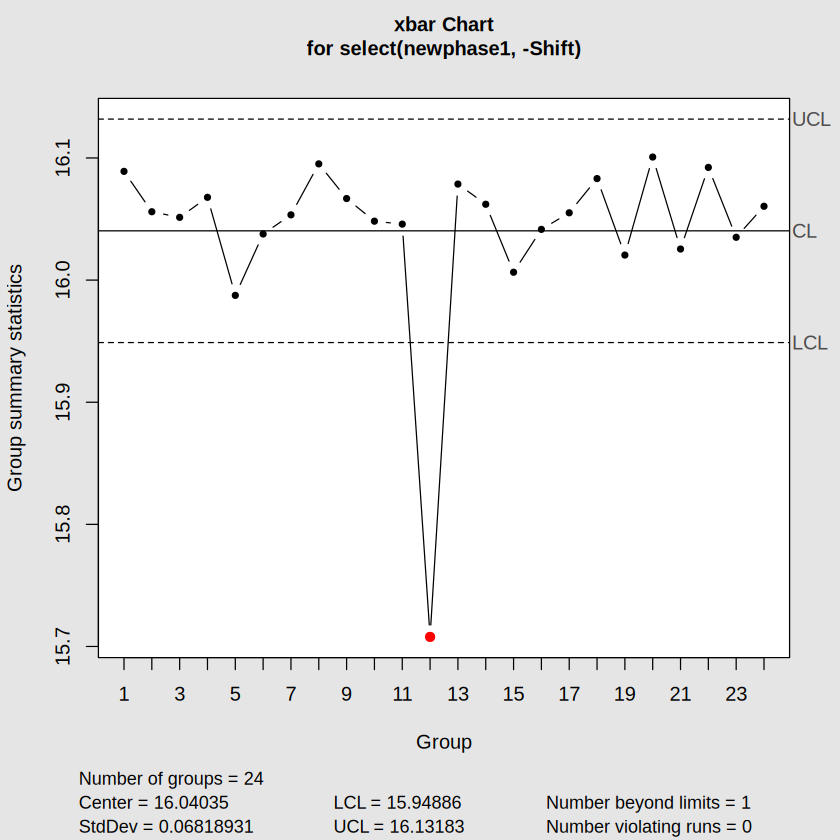

List of 11
 $ call      : language qcc(data = select(newphase1x, -Shift), type = "xbar", plot = TRUE)
 $ type      : chr "xbar"
 $ data.name : chr "select(newphase1x, -Shift)"
 $ data      : num [1:23, 1:5] 16 16.1 16.1 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:23] 16.1 16.1 16.1 16.1 16 ...
  ..- attr(*, "names")= chr [1:23] "1" "2" "3" "4" ...
 $ sizes     : int [1:23] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16.1
 $ std.dev   : num 0.0762
 $ nsigmas   : num 3
 $ limits    : num [1, 1:2] 15.9 16.2
  ..- attr(*, "dimnames")=List of 2
 $ violations:List of 2
 - attr(*, "class")= chr "qcc"

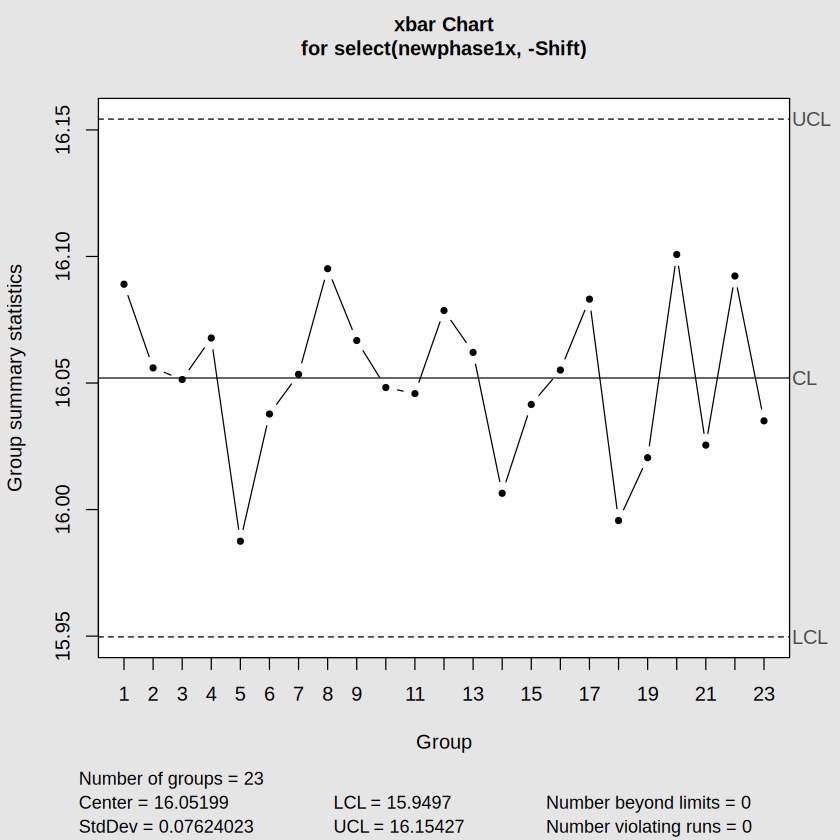

In [13]:
## Q6 Code ##

#New data

phase1_x <- qcc(newphase1 |> select(-`Shift`),
                 type = "xbar",
                 plot = TRUE)
                 (phase1_x)

ooc_indices_X <- phase1_x$violations$beyond.limits
print(ooc_indices_X)

cleanphase2 <- setdiff(1:nrow(newphase1), ooc_indices_X)
newphase1x <- BSPhase1_df[cleanphase2, ]

phase1_Xnew <- qcc(newphase1x |> select(-`Shift`),
                 type = "xbar",
                 plot = TRUE)
                 (phase1_Xnew)

Generating the new X bar chart with the subgroups retained from our analysis with the R chart showed that there was not complete evidence of statistical control just yet. The chart showed that subgroup 12 well exceeded the lower control limit straying further away from the desired center of 16 ounces for pour consistency. The charts seem to agree that there were OOC points causing inconsistencies with the pouring mechanic with the variation and the mean exceeding the control limits in those respective areas. Since the general manager is noticing that the CO2 regulator is slighltly under pouring the X bar chart gives evidence that the main defective issue of the regulator is that it is under pouring below the target mean of 16 oz per drink. Once removing this OOC subgroup we were able to achieve statistical control with no groups beyond or below the limits and no violating runs.

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

FNC: 1 

Process Capability Analysis

Call:
process.capability(object = phase1_Xnew, spec.limits = c(15.8,     16.2), target = 16, std.dev = phase1_Xnew$std.dev, nsigmas = 3)

Number of obs = 115          Target = 16
       Center = 16.05           LSL = 15.8
       StdDev = 0.07624         USL = 16.2

Capability indices:

       Value    2.5%   97.5%
Cp    0.8744  0.7610  0.9877
Cp_l  1.1017  0.9713  1.2322
Cp_u  0.6471  0.5601  0.7342
Cp_k  0.6471  0.5434  0.7509
Cpm   0.7225  0.6154  0.8293

Exp<LSL 0.047%	 Obs<LSL 0.87%
Exp>USL 2.6%	 Obs>USL 3.5%


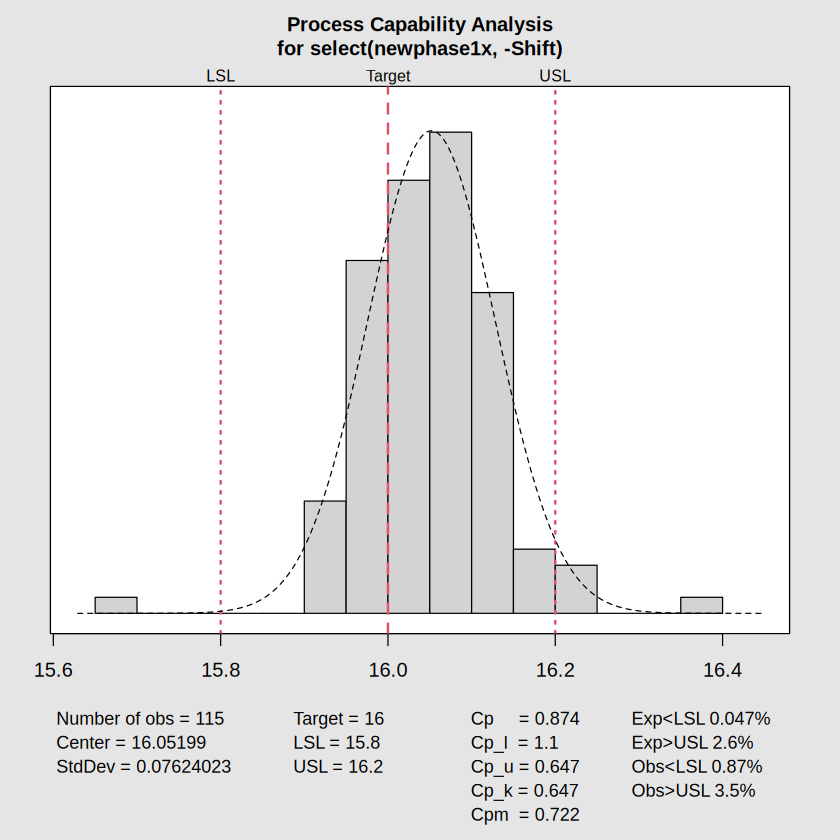

In [32]:
## Q7 Code ##

## Estimating Process Capability ##

FNC <- pnorm(1,mean=phase1_Xnew$center,
      sd=phase1_Xnew$std.dev) +
pnorm(2,mean=phase1_Xnew$center,sd=phase1_Xnew$std.dev,
      lower.tail=FALSE)

cat("FNC:", FNC, "\n")

process.capability(phase1_Xnew,
                 spec.limits=c(15.8,16.2),
                 target=16.00,
                  std.dev=phase1_Xnew$std.dev,
                   nsigmas=3)


## Cp ##
 - $CP$ = .874, which means that the difference between USL & LSL is .874 times the difference between UCL & LCL. This is not a good sign and more evidence is shown with how the histogram is not well centered.

## FNC ##
- From the chart, $Exp<LSL$ + $Exp>USL$ = >1 This is not a very good detail because it represents a tremendous chance of nonconforming units being developed. ##

## Cpk ##

- From the chart, we can see that $Cpk$ is .647, which is also not great detailing that the process is potentially not capable since the value is greater less than 1 and the histogram is not centered.

## Cpm ##

- The Cpm = .722 which is .075 points higher than the Cpk, Although it is higher it still is consistent with the other metrics that the process is incapable.

Overall all of the evidence points toward the process being incapable and with a higher chance of defective units being developed which in this context would be slighlty lower pour consistency for each drink.

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

(a). The Cusum Slack value K will be 0.5 and the decision interval H will be 5.These values are generally the rule of thumb where  h=4  or  5  and  k=0.50.
The Sample means were standardized using the estimated standard deviation, which is why we could just use  H=5  and  K=0.50  directly.

(b). The EWMA smoothing constant lambda = .05 and L = 2.615. We want to detect small shifts according to the general manager so setting the parameters to these values will help catch the shift since the process standard deviation estimated earlier was less than 1.

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [20]:
#creating the new final phase 1 process mean and standard deviation to use for the CUSUM and EWMA charts
newphase1_new <- newphase1x |>
  rowwise() |>
  mutate(
    subgroup_mean = mean(c(Pour1, Pour2, Pour3, Pour4, Pour5)),
    subgroup_range = max(c(Pour1, Pour2, Pour3, Pour4, Pour5)) -
                     min(c(Pour1, Pour2, Pour3, Pour4, Pour5))
  ) |>
  ungroup()


# Process mean = mean of subgroup means
process_mean <- mean(newphase1_new$subgroup_mean)

# Average range
Rbar <- mean(newphase1_new$subgroup_range)

# d2 constant for subgroup size n = 5
d2 <- 2.326

# Range-based estimate of sigma
sigma_hat <- Rbar / d2

cat("Process Mean:", process_mean, "\n")
cat("Process Standard Deviation (Using the Range Method):", sigma_hat, "\n")

Process Mean: 16.05199 
Process Standard Deviation (Using the Range Method): 0.07624023 


[1] 16.05199

List of 14
 $ call             : language cusum(data = BSPhase2_df, sizes = 5, center = mu02, decision.interval = h,      se.shift = k * 2, plot = T, sigma = sigma_std)
 $ type             : chr "cusum"
 $ data.name        : chr "BSPhase2_df"
 $ data             : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes            : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16.1
 $ std.dev          : num 2.84
 $ pos              : num [1:20] 0 0 0 0 0 0 0 0 0 0 ...
 $ neg              : num [1:20] -1.45 -2.82 -4.05 -5.15 -6.09 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

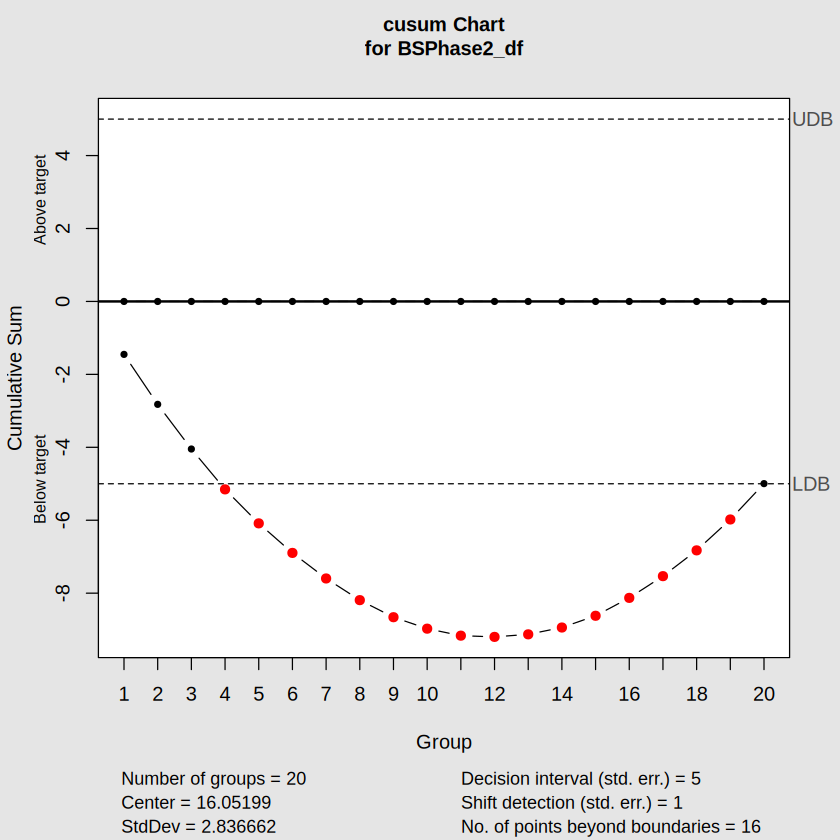

In [34]:
## Q9 Code ##
## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Data ##

BSPhase2_df <- read_excel("BustersSportsBar_PhaseII.xlsx")



#Gathering the final phase 1 process mean and standard deviation from the final phase 1 X bar chart from Q.6
mu02 <- 16.05199
mu02
sigma_std <- 0.07624023


k <- 0.5
h <- 5
#CUSUM chart with the final phase 1 Process mean and Process standard deviation
cusum(BSPhase2_df,sizes=5,center=mu02,sigma=sigma_std,se.shift=k*2,
      decision.interval = h,plot=T)










Once constructing the CUSUM chart it was noticeable that chart signaled an Out of Control condition with shift number 4 going beyond the boundaries and continuing on downward into shift 20.

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

Rows: 20
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0792, 16.0338, 16.0122, 16.0267, 16.0398, 16.0597, 16.0523, 1…
$ Pour2 <dbl> 16.1017, 16.0037, 16.0499, 16.0925, 16.1340, 16.1104, 16.0450, 1…
$ Pour3 <dbl> 16.1325, 16.0427, 16.1096, 15.8856, 16.0590, 16.0148, 16.0159, 1…
$ Pour4 <dbl> 16.0593, 15.9930, 16.0066, 16.1227, 16.1007, 15.9631, 16.0345, 1…
$ Pour5 <dbl> 16.0851, 16.0053, 16.0047, 15.9553, 16.0776, 16.1903, 16.0249, 1…


List of 15
 $ call      : language ewma(data = BSPhase2_df, center = mu02, lambda = 0.05, nsigmas = 2.615,      sigma = sigma_std)
 $ type      : chr "ewma"
 $ data.name : chr "BSPhase2_df"
 $ data      : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 16.1
 $ std.dev   : num 2.6
 $ x         : int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:20] 15.9 15.8 15.7 15.6 15.6 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sigma     : num [1:20] 0.0532 0.0733 0.0876 0.0988 0.1078 ...
 $ lambda    : num 0.05
 $ nsigmas   : num 2.62
 $ limits    : num [1:20, 1:2] 15.9 15.9 15.8 15.8 15.8 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:19] 2 3 4 5 6 7 8 9 10 11 ...
  ..- attr(*, "names")= chr [1:19] "2" "3" "4" "5" ...
 - attr(*, "class"

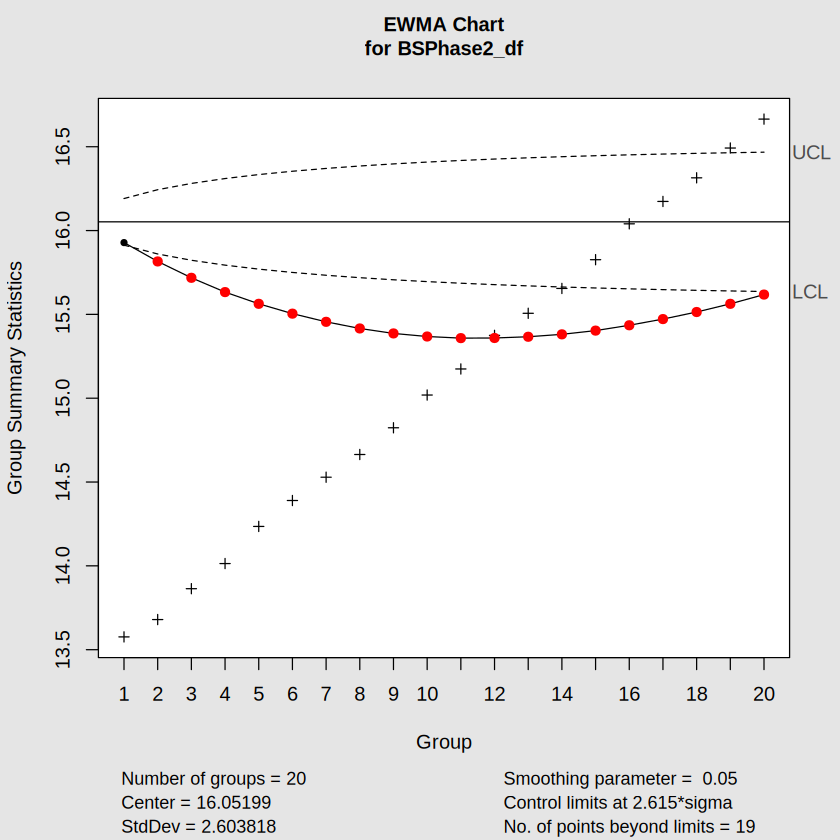

In [36]:
## Q10 Code ##

## Data Integrity Check ##

BSPhase2_df |>
  glimpse()
#Original method EWMA chart using shift means and shift process standard deviation
ewma(BSPhase2_df,center=mu02,sigma=sigma_std,lambda=0.05,nsigmas=2.615)


Once constructing the EWMA chart it was noticeable that chart signaled an Out of Control condition with shift number 2 going beyond the boundaries and continuing on a downward curve into shift 20.

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

List of 14
 $ call             : language cusum(data = BSPhase2_df, sizes = 5, center = mu02, decision.interval = h,      se.shift = k * 2, plot = T, sigma = sigma_std)
 $ type             : chr "cusum"
 $ data.name        : chr "BSPhase2_df"
 $ data             : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes            : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16.1
 $ std.dev          : num 2.84
 $ pos              : num [1:20] 0 0 0 0 0 0 0 0 0 0 ...
 $ neg              : num [1:20] -1.45 -2.82 -4.05 -5.15 -6.09 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

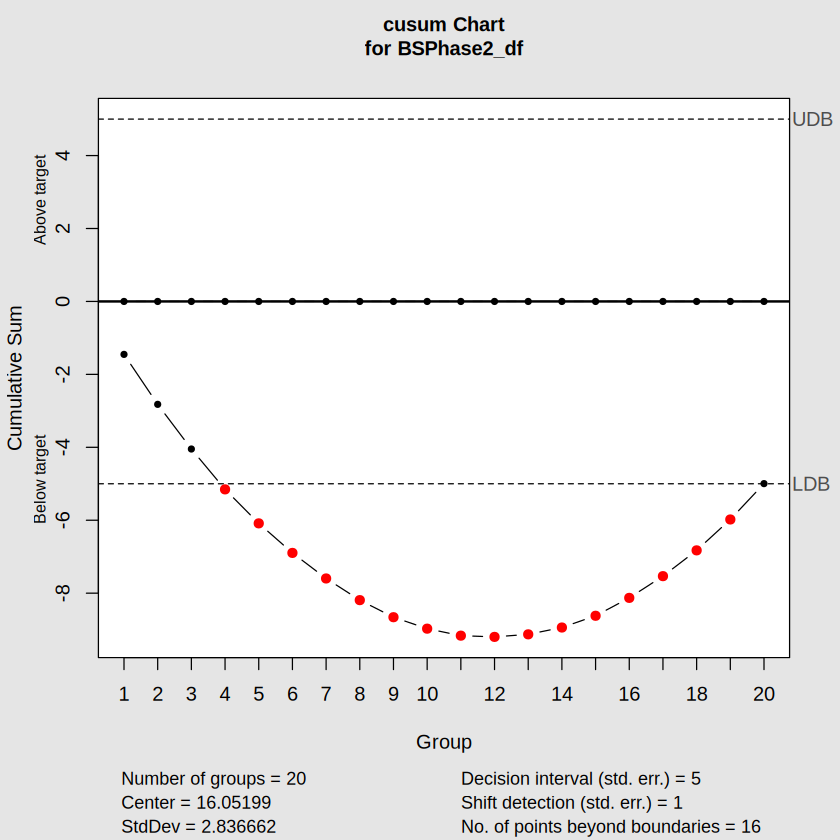

List of 15
 $ call      : language ewma(data = BSPhase2_df, center = mu02, lambda = 0.05, nsigmas = 2.615,      sigma = sigma_std)
 $ type      : chr "ewma"
 $ data.name : chr "BSPhase2_df"
 $ data      : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 16.1
 $ std.dev   : num 2.6
 $ x         : int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:20] 15.9 15.8 15.7 15.6 15.6 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sigma     : num [1:20] 0.0532 0.0733 0.0876 0.0988 0.1078 ...
 $ lambda    : num 0.05
 $ nsigmas   : num 2.62
 $ limits    : num [1:20, 1:2] 15.9 15.9 15.8 15.8 15.8 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:19] 2 3 4 5 6 7 8 9 10 11 ...
  ..- attr(*, "names")= chr [1:19] "2" "3" "4" "5" ...
 - attr(*, "class"

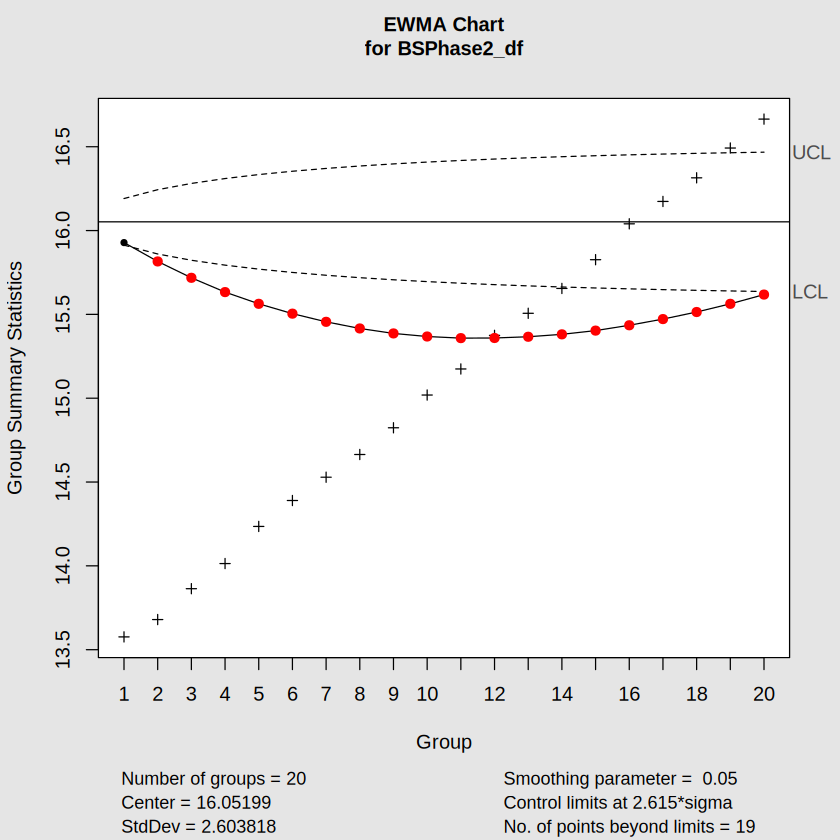

In [37]:
## Q11 Code ##

#CUSUM chart with the final phase 1 Process mean and Process standard deviation
cusum(BSPhase2_df,sizes=5,center=mu02,sigma=sigma_std,se.shift=k*2,
      decision.interval = h,plot=T)
#Method using process mean and process standard deviation from final phase 1 estimates
ewma(BSPhase2_df,center=mu02,sigma=sigma_std,lambda=0.05,nsigmas=2.615)




Evaluating both charts it seemed that the EWMA chart was able to detect the shift quicker starting at group 2 rather than group 4 in the CUSUM chart. This is somewhat surprising, because although very similar CUSUM charts are generally more sensitive than EWMA charts to small, sustained shifts in the process mean. However, since in context the general manager wanted a reliable tool to detect a small shift in the mean by less than or equal to one process standard deviation the metrics chosen for the EWMA chart were able to detect this very small shift alot more faster than the general metrics chosen for the CUSUM chart.

### Q12: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?

Based upon the evidence collected the general manager should report that the CO2 regulator needs to be replaced way ahead of schedule. In context many patrons are coming into the bar for the draft beer program and foam may be nice to top off the beer it should not be the main base of what they are drinking. The results from the initial phase 1 investigation provided by the R and X bar charts indicated that the CO2 regulator was underperforming and alerted us to many possible defective issues especially with the process Capability analysis. These results gained further support with the CUSUM and EWMA charts as they were able to detect the small inconsistent shifts with the CO2 regulator. For the first couple of pours it started underperforming much to the general manager's suspicion. Overall to maintain business revenue, and customer satisfaction the C02 regulator must be replaced to ensure that it wouldn't be producing more foam then actual beer for the customers in the establishment.